<a href="https://colab.research.google.com/github/Deepikadandolu/Tsetlin_Machines_Projects/blob/main/diabetes_Tsetlin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pyTsetlinMachine

  Preparing metadata (setup.py) ... done
  Created wheel for pyTsetlinMachine: filename=pyTsetlinMachine-0.6.6-cp312-cp312-linux_x86_64.whl size=59512 sha256=df4ff460c72c59ed62f81392f50b1c8219830e7360782b053b764cd8fb99ae6f
  Stored in directory: /root/.cache/pip/wheels/5a/1b/7a/ac7b5840c6328372b929a1b0ff5bd0fe6ce147d1e762f14159
Successfully built pyTsetlinMachine


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from pyTsetlinMachine.tm import MultiClassTsetlinMachine


In [3]:
path = kagglehub.dataset_download(
    "alexteboul/diabetes-health-indicators-dataset"
)
print("Dataset Path:", path)

Using Colab cache for faster access to the 'diabetes-health-indicators-dataset' dataset.
Dataset Path: /kaggle/input/diabetes-health-indicators-dataset


In [4]:
import os
print(os.listdir(path))

['diabetes_binary_5050split_health_indicators_BRFSS2015.csv', 'diabetes_binary_health_indicators_BRFSS2015.csv', 'diabetes_012_health_indicators_BRFSS2015.csv']


In [5]:
csv_path = os.path.join(
    path,
    "diabetes_012_health_indicators_BRFSS2015.csv"
)

df = pd.read_csv(csv_path)

In [6]:
df.head()
print(df.shape)

(253680, 22)


In [7]:
print(df.isnull().sum())

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


In [8]:
df = df.drop_duplicates()

In [9]:
print(df.shape)

(229781, 22)


In [10]:
print(df['Diabetes_012'].value_counts())

Diabetes_012
0.0    190055
2.0     35097
1.0      4629
Name: count, dtype: int64


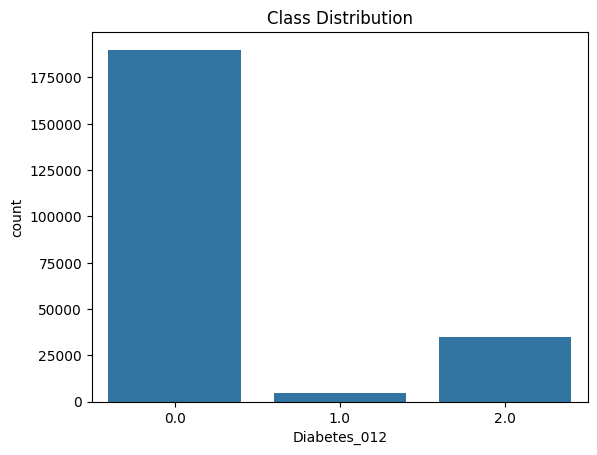

In [11]:
sns.countplot(x='Diabetes_012', data=df)
plt.title("Class Distribution")
plt.show()

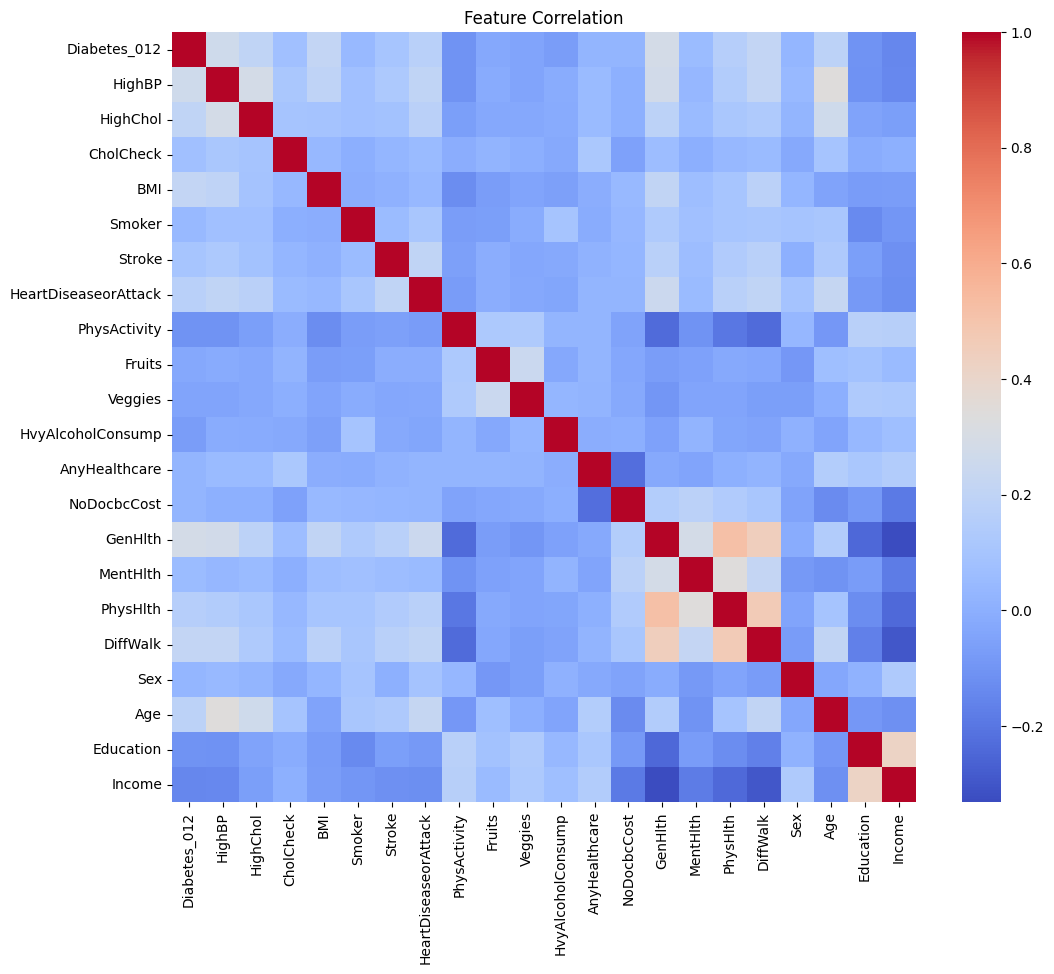

In [12]:
plt.figure(figsize=(12,10))

sns.heatmap(df.corr(), cmap='coolwarm')

plt.title("Feature Correlation")
plt.show()

In [13]:
X = df.drop("Diabetes_012", axis=1)

y = df["Diabetes_012"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
kbd = KBinsDiscretizer(
    n_bins=5,
    encode='onehot-dense',
    strategy='uniform'
)

In [15]:
X_train_bin = kbd.fit_transform(X_train)

X_test_bin = kbd.transform(X_test)

In [16]:
print(X_train_bin.shape)
print(X_test_bin.shape)

(183824, 105)
(45957, 105)


In [17]:
tm = MultiClassTsetlinMachine(
    number_of_clauses=2000,
    T=1000,
    s=5.0
)
epochs = 50
accuracy_list = []
for epoch in range(epochs):
    tm.fit(X_train_bin, y_train, epochs=1)
    y_pred = tm.predict(X_test_bin)
    acc = accuracy_score(y_test, y_pred)
    accuracy_list.append(acc)
    print(f"Epoch {epoch+1}: Accuracy = {acc:.4f}")

Epoch 1: Accuracy = 0.7800
Epoch 2: Accuracy = 0.7904
Epoch 3: Accuracy = 0.7827
Epoch 4: Accuracy = 0.7835
Epoch 5: Accuracy = 0.7769
Epoch 6: Accuracy = 0.7870
Epoch 7: Accuracy = 0.7826
Epoch 8: Accuracy = 0.7907
Epoch 9: Accuracy = 0.7888
Epoch 10: Accuracy = 0.7898
Epoch 11: Accuracy = 0.7865
Epoch 12: Accuracy = 0.7798
Epoch 13: Accuracy = 0.7806
Epoch 14: Accuracy = 0.7847
Epoch 15: Accuracy = 0.7840
Epoch 16: Accuracy = 0.7840
Epoch 17: Accuracy = 0.7787
Epoch 18: Accuracy = 0.7837
Epoch 19: Accuracy = 0.7802
Epoch 20: Accuracy = 0.7910
Epoch 21: Accuracy = 0.7864
Epoch 22: Accuracy = 0.7880
Epoch 23: Accuracy = 0.7841
Epoch 24: Accuracy = 0.7814
Epoch 25: Accuracy = 0.7805
Epoch 26: Accuracy = 0.7860
Epoch 27: Accuracy = 0.7754
Epoch 28: Accuracy = 0.7860
Epoch 29: Accuracy = 0.7822
Epoch 30: Accuracy = 0.7815
Epoch 31: Accuracy = 0.7844
Epoch 32: Accuracy = 0.7769
Epoch 33: Accuracy = 0.7831
Epoch 34: Accuracy = 0.7920
Epoch 35: Accuracy = 0.7887
Epoch 36: Accuracy = 0.7823
E

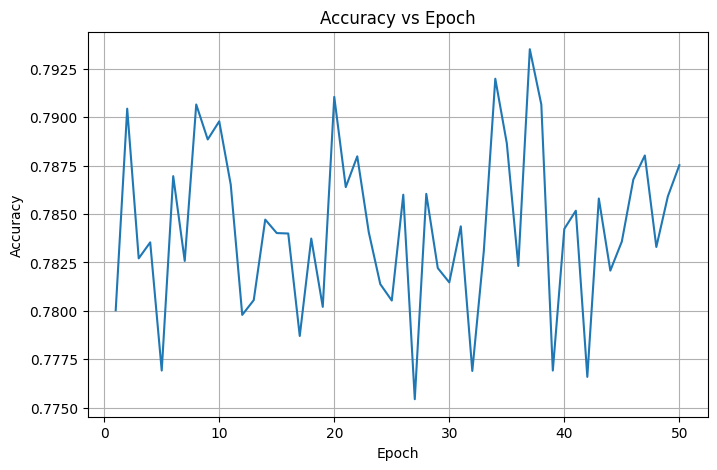

In [22]:
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs + 1), accuracy_list)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.grid(True)
plt.show()

In [18]:
y_pred = tm.predict(X_test_bin)


Accuracy: 0.7875187675435733
              precision    recall  f1-score   support

         0.0       0.88      0.87      0.87     38012
         1.0       0.03      0.00      0.00       926
         2.0       0.37      0.43      0.40      7019

    accuracy                           0.79     45957
   macro avg       0.43      0.44      0.43     45957
weighted avg       0.78      0.79      0.79     45957

[[33152    60  4800]
 [  644     2   280]
 [ 3978     3  3038]]


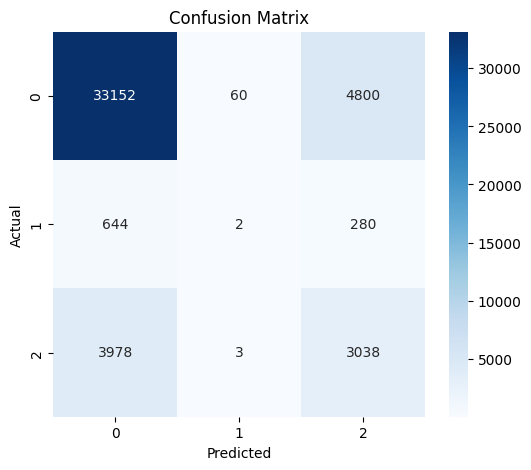

In [19]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

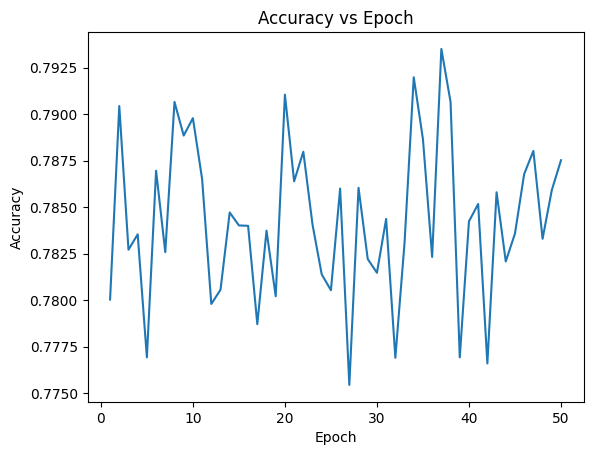

In [20]:
plt.plot(range(1, epochs+1), accuracy_list)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.show()

In [21]:
import pickle
with open("tsetlin_diabetes_model.pkl", "wb") as file:
    pickle.dump(tm, file)